# 🔬 Pipeline Completo de Análise de Fidelidade Semântica - Orlando Furioso

Este notebook implementa o pipeline completo de análise, integrando todos os módulos criados.

**Etapas:**
1. Carregamento dos dados parseados
2. Geração de embeddings multilíngues
3. Treinamento de MLPs autoassociativas
4. Cálculo de fidelidade semântica
5. Análise e visualização dos resultados

**Objetivo:** Comparar a fidelidade semântica das traduções de William Stewart Rose e John Harington em relação ao original italiano de Ludovico Ariosto.

## 📦 1. Configuração e Imports

In [36]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Importar módulos customizados
from data_processing import load_and_parse_all
from embeddings import generate_embeddings_from_dataframe
from models import train_multiple_autoencoders, test_reconstruction_quality
from similarity import (
    calculate_fidelity_scores,
    add_fidelity_to_dataframe,
    print_fidelity_summary,
    get_extreme_stanzas
)
from visualization import (
    plot_training_curves,
    plot_fidelity_by_canto,
    plot_fidelity_distribution
)

# Configuração de visualização
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Seeds para reprodutibilidade
np.random.seed(93)
torch.manual_seed(93)

# Configuração do dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(93)
    print("🎮 GPU disponível! Usando CUDA.")
else:
    print("💻 GPU não disponível. Usando CPU.")

print("\n✅ Imports concluídos com sucesso!")
print(f"   PyTorch version: {torch.__version__}")
print(f"   Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

🎮 GPU disponível! Usando CUDA.

✅ Imports concluídos com sucesso!
   PyTorch version: 2.5.1+cu121
   Device: CUDA


## 📂 2. Carregamento dos Dados

Carregar o DataFrame parseado do notebook anterior (ou reprocessar se necessário).

In [37]:
# Tentar carregar dados já parseados
try:
    df = pd.read_csv('../outputs/data/orlando_furioso_parsed.csv')
    print("✅ Dados carregados do arquivo CSV existente.")
except FileNotFoundError:
    print("⚠️  Arquivo CSV não encontrado. Reprocessando dados...")
    df = load_and_parse_all(data_dir='../data')
    df.to_csv('../outputs/data/orlando_furioso_parsed.csv', index=False, encoding='utf-8')
    print("✅ Dados reprocessados e salvos.")

print(f"\n📊 DataFrame carregado:")
print(f"   Dimensões: {df.shape[0]} estrofes × {df.shape[1]} colunas")
print(f"   Cantos: {df['canto'].min()} a {df['canto'].max()}")
print(f"   Total de cantos únicos: {df['canto'].nunique()}")

✅ Dados carregados do arquivo CSV existente.

📊 DataFrame carregado:
   Dimensões: 4842 estrofes × 5 colunas
   Cantos: 1 a 46
   Total de cantos únicos: 46


### 🔍 Verificação: Primeiras linhas do DataFrame e valores ausentes

In [38]:
display(df.head())

print("\n📋 Informações do DataFrame:")
df.info()

print("\n⚠️ Valores Ausentes:")
print("Valores nulos:")
print(df.isnull().sum())

print("\nStrings vazias:")
for col in ['italian', 'william', 'john']:
    empty_count = (df[col] == '').sum()
    print(f"{col}: {empty_count} ({empty_count/len(df)*100:.2f}%)")

,canto,estrofe,italian,william,john
0,1,1,"Le donne, i cavallier, l'arme, gli amori,\nle cortesie, l'audaci imprese io canto,\nche furo al ...","OF LOVES and LADIES, KNIGHTS and ARMS, I sing,\nOf COURTESIES, and many a DARING FEAT;\nAnd from...","Of Dames, of Knights, of armes, of loves delight,\nOf courtesies, of high attempts I speake,\nTh..."
1,1,2,"Dirò d'Orlando in un medesmo tratto\ncosa non detta in prosa mai, né in rima:\nche per amor venn...","In the same strain of Roland will I tell\nThings unattempted yet in prose or rhyme,\nOn whom str...","I will no lesse Orlandos acts declare,\n(A tale in prose ne verse yet sung or said)\nWho fell be..."
2,1,3,"Piacciavi, generosa Erculea prole,\nornamento e splendor del secol nostro,\nIppolito, aggradir q...","Good seed of Hercules, give ear and deign,\nThou that this age's grace and splendour art,\nHippo...","Vouchsafe (O Prince of most renowned race,\nThe ornament and hope of this our time)\nTaccept thi..."
3,1,4,"Voi sentirete fra i più degni eroi,\nche nominar con laude m'apparecchio,\nricordar quel Ruggier...","And me, amid the worthiest shalt thou hear,\nWhom I with fitting praise prepare to grace,\nRecor...","Here shall you find among the worthy peeres,\nWhose praises I prepare to tell in verse,\nRogero,..."
4,1,5,"Orlando, che gran tempo innamorato\nfu de la bella Angelica, e per lei\nin India, in Media, in T...","Roland, who long the lady of Catay,\nAngelica, had loved, and with his brand\nRaised countless t...","Orlando who long time had loved deare,\nAngelica the faire: and for her sake,\nAbout the world, ..."



📋 Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4842 entries, 0 to 4841
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   canto    4842 non-null   int64 
 1   estrofe  4842 non-null   int64 
 2   italian  4842 non-null   object
 3   william  4821 non-null   object
 4   john     4114 non-null   object
dtypes: int64(2), object(3)
memory usage: 189.3+ KB

⚠️ Valores Ausentes:
Valores nulos:
canto        0
estrofe      0
italian      0
william     21
john       728
dtype: int64

Strings vazias:
italian: 0 (0.00%)
william: 0 (0.00%)
john: 0 (0.00%)


## 🧬 3. Geração de Embeddings

Utiliza o modelo `SentenceTransformer` para criar representações vetoriais multilíngues das estrofes.

**Modelo:** `paraphrase-multilingual-MiniLM-L12-v2`
- Dimensão: 384
- Otimizado para textos multilíngues
- Preserva acentos, elisões e pontuação (importante para italiano)

In [39]:
# Gerar embeddings (isso pode levar alguns minutos)
print("\n" + "="*50)
print(" "*10 + "INICIANDO GERAÇÃO DE EMBEDDINGS")
print("="*50)
print("\n⏳ Este processo pode levar vários minutos dependendo do hardware...")

embeddings_raw, embeddings_scaled = generate_embeddings_from_dataframe(
    df=df,
    model_name='paraphrase-multilingual-MiniLM-L12-v2',
    save_path='../outputs/embeddings',
    batch_size=32
)

print("\n" + "="*50)
print(       "INICIANDO VERIFICAÇÃO DE EMBEDDINGS")
print("="*50)

print("\n📊 Verificação dos Embeddings Gerados:")
print("\n🔸 Embeddings RAW (não escalonados):")
for lang, emb in embeddings_raw.items():
    print(f"   {lang}: {emb.shape}")
    print(f"      Min: {emb.min():.4f}, Max: {emb.max():.4f}, Mean: {emb.mean():.4f}")

print("\n🔹 Embeddings SCALED (normalizados):")
for lang, emb in embeddings_scaled.items():
    print(f"   {lang}: {emb.shape}")
    print(f"      Min: {emb.min():.4f}, Max: {emb.max():.4f}, Mean: {emb.mean():.4f}, Std: {emb.std():.4f}")


          INICIANDO GERAÇÃO DE EMBEDDINGS

⏳ Este processo pode levar vários minutos dependendo do hardware...
📥 Carregando modelo de embeddings: paraphrase-multilingual-MiniLM-L12-v2...
✅ Modelo carregado com sucesso!
   Dimensão dos embeddings: 384

               GERANDO EMBEDDINGS               


🇮🇹 ITALIANO (Original):
🔄 Gerando embeddings para 4842 textos...


Batches:   0%|          | 0/152 [00:00<?, ?it/s]

✅ Embeddings gerados! Shape: (4842, 384)

🇬🇧 WILLIAM STEWART ROSE:
🔄 Gerando embeddings para 4842 textos...


Batches:   0%|          | 0/152 [00:00<?, ?it/s]

✅ Embeddings gerados! Shape: (4842, 384)

🇬🇧 JOHN HARINGTON:
🔄 Gerando embeddings para 4842 textos...


Batches:   0%|          | 0/152 [00:00<?, ?it/s]

✅ Embeddings gerados! Shape: (4842, 384)

               ESCALONANDO EMBEDDINGS               

📏 Escalonando embeddings...
   Scaler ajustado em 14526 amostras
   ✓ italian: (4842, 384)
   ✓ william: (4842, 384)
   ✓ john: (4842, 384)
✅ Escalonamento concluído!

               SALVANDO EMBEDDINGS               

💾 Salvando embeddings em ..\outputs\embeddings...
   ✓ ..\outputs\embeddings\embeddings_raw_italian.npy
   ✓ ..\outputs\embeddings\embeddings_raw_william.npy
   ✓ ..\outputs\embeddings\embeddings_raw_john.npy
   ✓ ..\outputs\embeddings\embeddings_raw_scaler.pkl
✅ Embeddings salvos com sucesso!
💾 Salvando embeddings em ..\outputs\embeddings...
   ✓ ..\outputs\embeddings\embeddings_scaled_italian.npy
   ✓ ..\outputs\embeddings\embeddings_scaled_william.npy
   ✓ ..\outputs\embeddings\embeddings_scaled_john.npy
   ✓ ..\outputs\embeddings\embeddings_scaled_scaler.pkl
✅ Embeddings salvos com sucesso!

INICIANDO VERIFICAÇÃO DE EMBEDDINGS

📊 Verificação dos Embeddings Gerados:

🔸 Embe

## 🤖 4. Treinamento das MLPs Autoassociativas

Treinar autoencoders para cada versão (italiano, william, john).

**Arquitetura:**
- Input: 384 dimensões (embeddings)
- Latent Space: 96 dimensões (compressão 4:1)
- Output: 384 dimensões (reconstrução)

**Objetivo:** Aprender representações compactas que capturam a essência semântica.

In [40]:
# Treinar autoencoders
results = train_multiple_autoencoders(
    embeddings_dict=embeddings_scaled,
    encoding_dim=None,  # None = input_dim // 4 (96 dimensões)
    epochs=100,
    batch_size=32,
    learning_rate=0.001,
    verbose=True
)

# Extrair resultados
trainers = results['trainers']
encoded_data = results['encoded']
losses = results['losses']


               TREINANDO AUTOENCODERS
Input dim: 384 → Encoding dim: 96
Compressão: 75.0%


🔵 Treinando Autoencoder: ITALIAN
✅ Autoencoder inicializado:
   Input dim: 384
   Encoding dim: 96
   Device: cuda
   Learning rate: 0.001

🔄 Iniciando treinamento:
   Amostras: 4842
   Épocas: 100
   Batch size: 32
   Batches por época: 152

   Epoch [20/100] - Loss: 0.070123
   Epoch [40/100] - Loss: 0.068423
   Epoch [60/100] - Loss: 0.068232
   Epoch [80/100] - Loss: 0.067613
   Epoch [100/100] - Loss: 0.067978

✅ Treinamento concluído!
   Perda final: 0.067978

🔵 Treinando Autoencoder: WILLIAM
✅ Autoencoder inicializado:
   Input dim: 384
   Encoding dim: 96
   Device: cuda
   Learning rate: 0.001

🔄 Iniciando treinamento:
   Amostras: 4842
   Épocas: 100
   Batch size: 32
   Batches por época: 152

   Epoch [20/100] - Loss: 0.170908
   Epoch [40/100] - Loss: 0.167794
   Epoch [60/100] - Loss: 0.166196
   Epoch [80/100] - Loss: 0.165717
   Epoch [100/100] - Loss: 0.165324

✅ Treinamento co

### 📉 Verificação: Curvas de Treinamento

📊 Gráfico salvo em: ../outputs/figures/training_curves.png


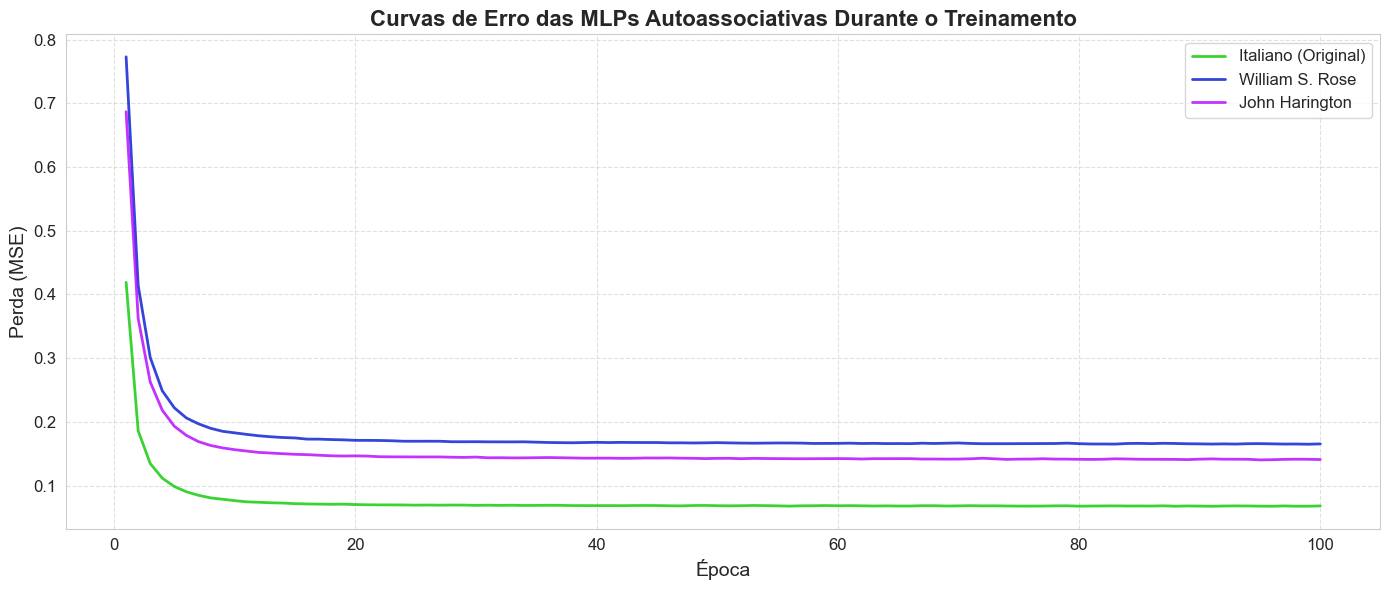


📊 Resumo do Treinamento:

🔹 Perda Final (MSE):
   ITALIAN: 0.067978
   WILLIAM: 0.165324
   JOHN: 0.140775

🔹 Dimensões das Representações Latentes:
   ITALIAN: (4842, 96)
      Min: 0.0000, Max: 6.8941, Mean: 1.5158
   WILLIAM: (4842, 96)
      Min: 0.0000, Max: 7.6568, Mean: 1.7930
   JOHN: (4842, 96)
      Min: 0.0000, Max: 6.7896, Mean: 1.5706


In [41]:
# Plotar curvas de erro
plot_training_curves(
    losses_dict=losses,
    save_path='../outputs/figures/training_curves.png'
)

print("\n📊 Resumo do Treinamento:")
print("\n🔹 Perda Final (MSE):")
for lang, loss_history in losses.items():
    print(f"   {lang.upper()}: {loss_history[-1]:.6f}")

print("\n🔹 Dimensões das Representações Latentes:")
for lang, encoded in encoded_data.items():
    print(f"   {lang.upper()}: {encoded.shape}")
    print(f"      Min: {encoded.min():.4f}, Max: {encoded.max():.4f}, Mean: {encoded.mean():.4f}")

### 🧪 Teste: Capacidade de Reconstrução

In [42]:
# Testar qualidade de reconstrução dos autoencoders
reconstruction_results = test_reconstruction_quality(
    trainers=trainers,
    embeddings_scaled=embeddings_scaled,
    device=device
)

# Resumo comparativo
print("\n📊 RESUMO COMPARATIVO:")
print(f"{'Versão':<12} {'MSE':<12} {'Perda (%)':<12} {'Compressão'}")
print("-" * 60)

for lang, metrics in reconstruction_results.items():
    compression = f"{metrics['input_shape'][1]}→{metrics['latent_shape'][1]}"
    print(f"{lang.upper():<12} {metrics['mse']:<12.6f} {metrics['loss_percentage']:<12.2f} {compression}")

print("\n✅ Todos os autoencoders testados com sucesso!")


🔬 TESTE DE QUALIDADE DE RECONSTRUÇÃO

📊 Testando: ITALIAN
   MSE: 0.073408
   Perda de informação: 7.75%
   ✅ Muito bom! (<10%)

📊 Testando: WILLIAM
   MSE: 0.115843
   Perda de informação: 9.63%
   ✅ Muito bom! (<10%)

📊 Testando: JOHN
   MSE: 0.164970
   Perda de informação: 14.79%
   ⚠️  Moderado (10-20%)


📊 RESUMO COMPARATIVO:
Versão       MSE          Perda (%)    Compressão
------------------------------------------------------------
ITALIAN      0.073408     7.75         384→96
WILLIAM      0.115843     9.63         384→96
JOHN         0.164970     14.79        384→96

✅ Todos os autoencoders testados com sucesso!


## 📐 5. Cálculo da Fidelidade Semântica

Calcular similaridade de cosseno entre as representações latentes do original italiano e as traduções.

**Métrica:** Similaridade de Cosseno
- Valores entre 0 e 1
- Próximo de 1 = alta fidelidade
- Próximo de 0 = baixa fidelidade

In [43]:
# Calcular fidelidade semântica
fidelity_scores = calculate_fidelity_scores(
    encoded_original=encoded_data['italian'],
    encoded_translations={
        'william': encoded_data['william'],
        'john': encoded_data['john']
    }
)

# Adicionar scores ao DataFrame
df_with_fidelity = add_fidelity_to_dataframe(
    df=df,
    fidelity_scores=fidelity_scores
)

# Imprimir resumo estatístico completo
print_fidelity_summary(
    df=df_with_fidelity,
    fidelity_columns=['fidelidade_semantica_william', 'fidelidade_semantica_john']
)

# Exemplo detalhado: Canto 1, Estrofe 1
example = df_with_fidelity[(df_with_fidelity['canto'] == 1) & (df_with_fidelity['estrofe'] == 1)].iloc[0]

print("\n" + "="*50)
print("      EXEMPLO DETALHADO: CANTO 1, ESTROFE 1")
print("="*50)

print("\nITALIANO (Original):")
print(f"   {example['italian'][:300]}..." if len(example['italian']) > 300 else f"   {example['italian']}")

print("\nWILLIAM STEWART ROSE:")
print(f"   {example['william'][:300]}..." if len(example['william']) > 300 else f"   {example['william']}")
print(f"   📊 Fidelidade: {example['fidelidade_semantica_william']:.4f}")

print("\nJOHN HARINGTON:")
print(f"   {example['john'][:300]}..." if len(example['john']) > 300 else f"   {example['john']}")
print(f"   📊 Fidelidade: {example['fidelidade_semantica_john']:.4f}")

print("\n" + "="*50)

# Obter estrofes extremas
top_william, bottom_william = get_extreme_stanzas(
    df=df_with_fidelity,
    fidelity_column='fidelidade_semantica_william',
    n_top=5,
    n_bottom=5
)

top_john, bottom_john = get_extreme_stanzas(
    df=df_with_fidelity,
    fidelity_column='fidelidade_semantica_john',
    n_top=5,
    n_bottom=5
)


print("\n⭐ TOP 5 - MAIOR FIDELIDADE (William):")
print(top_william[['canto', 'estrofe', 'fidelidade_semantica_william']])

print("\n⚠️ BOTTOM 5 - MENOR FIDELIDADE (William):")
print(bottom_william[['canto', 'estrofe', 'fidelidade_semantica_william']])


print("\n⭐ TOP 5 - MAIOR FIDELIDADE (John):")
print(top_john[['canto', 'estrofe', 'fidelidade_semantica_john']])

print("\n⚠️ BOTTOM 5 - MENOR FIDELIDADE (John):")
print(bottom_john[['canto', 'estrofe', 'fidelidade_semantica_john']])

✓ Coluna adicionada: fidelidade_semantica_william
✓ Coluna adicionada: fidelidade_semantica_john

     RESUMO ESTATÍSTICO DA FIDELIDADE SEMÂNTICA

📊 WILLIAM:
   Média: 0.8087
   Mediana: 0.8134
   Desvio padrão: 0.0502
   Mínimo: 0.2240
   Máximo: 0.9119
   Q1 (25%): 0.7879
   Q3 (75%): 0.8374

   Distribuição por categoria:
      Alta fidelidade (≥0.80): 3090 (63.8%)
      Média fidelidade (0.60-0.80): 1731 (35.7%)
      Baixa fidelidade (<0.60): 21 (0.4%)


📊 JOHN:
   Média: 0.7365
   Mediana: 0.8009
   Desvio padrão: 0.1707
   Mínimo: 0.1945
   Máximo: 0.9090
   Q1 (25%): 0.7597
   Q3 (75%): 0.8285

   Distribuição por categoria:
      Alta fidelidade (≥0.80): 2452 (50.6%)
      Média fidelidade (0.60-0.80): 1662 (34.3%)
      Baixa fidelidade (<0.60): 728 (15.0%)


      EXEMPLO DETALHADO: CANTO 1, ESTROFE 1

ITALIANO (Original):
   Le donne, i cavallier, l'arme, gli amori,
le cortesie, l'audaci imprese io canto,
che furo al tempo che passaro i Mori
d'Africa il mare, e in Francia n

## 🎨 6. Visualizações

### 📉 Fidelidade por Canto

📊 Gráfico salvo em: ../outputs/figures/fidelity_by_canto.png


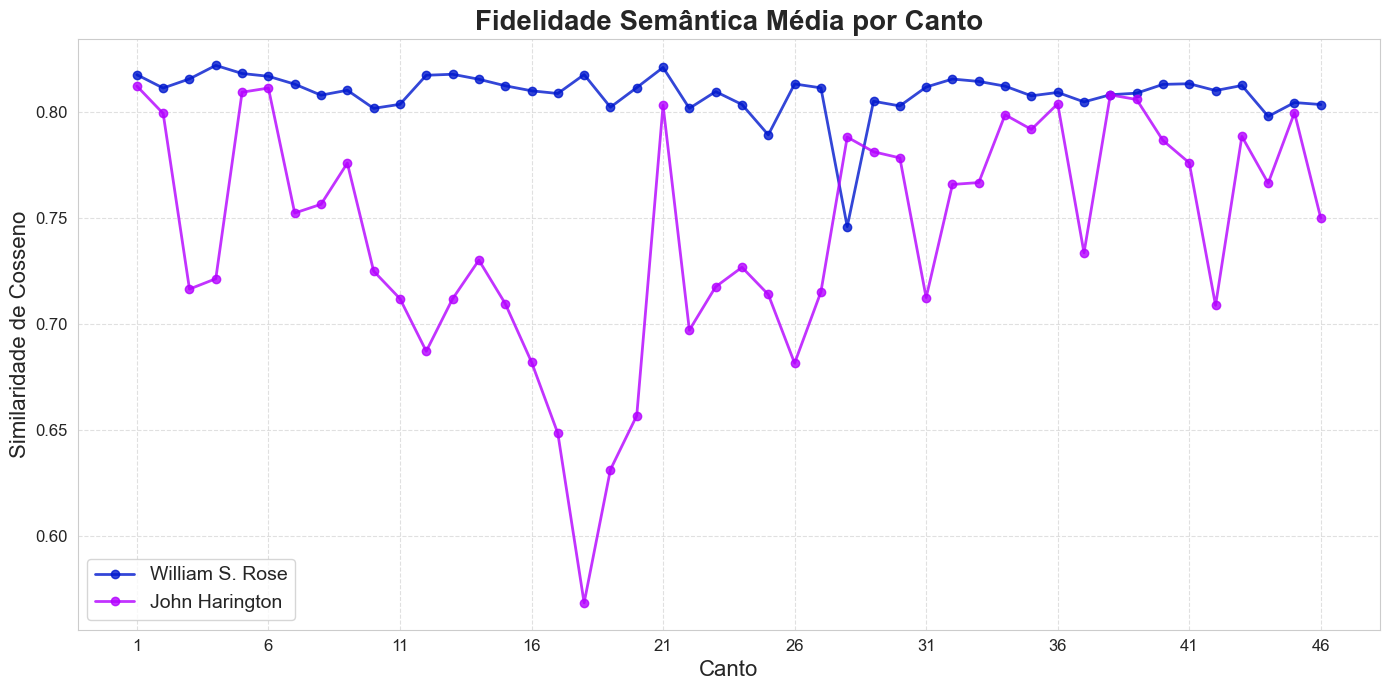

In [44]:
plot_fidelity_by_canto(
    df=df_with_fidelity,
    fidelity_columns=['fidelidade_semantica_william', 'fidelidade_semantica_john'],
    save_path='../outputs/figures/fidelity_by_canto.png'
)

### 📊 Distribuição de Fidelidade

c:\Users\joaov\AppData\Local\pypoetry\Cache\virtualenvs\labrna-MRCAsK2D-py3.11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\joaov\AppData\Local\pypoetry\Cache\virtualenvs\labrna-MRCAsK2D-py3.11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


📊 Gráfico salvo em: ../outputs/figures/fidelity_distribution.png


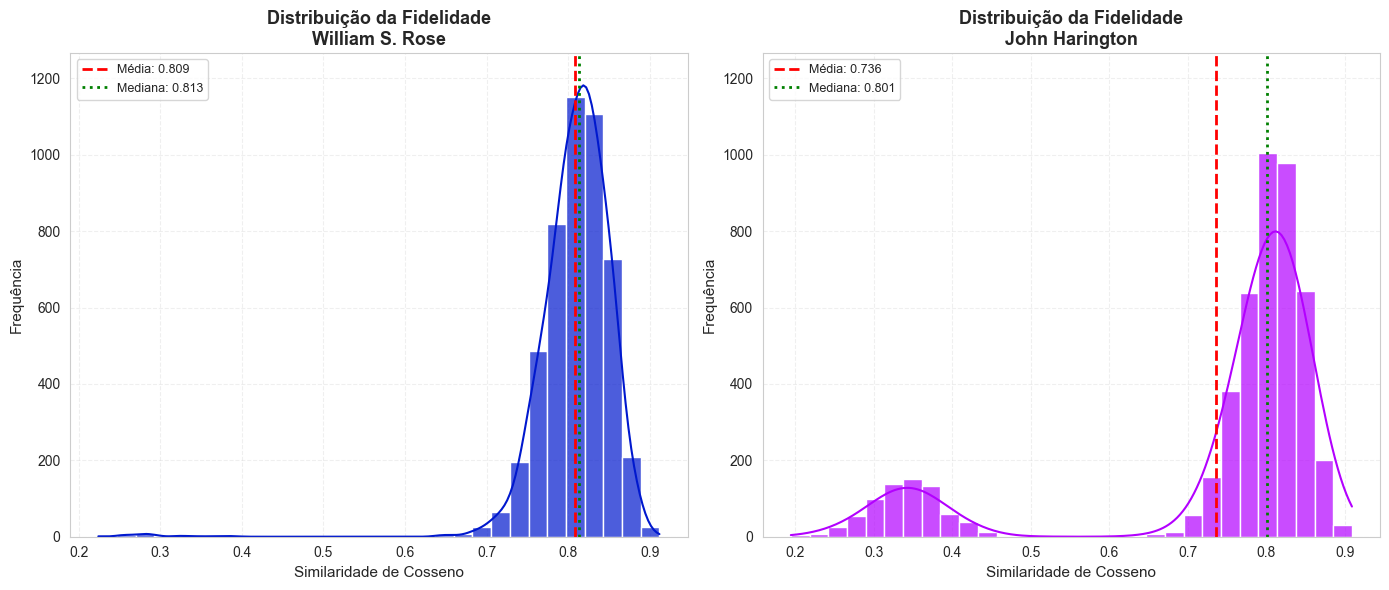

In [45]:
plot_fidelity_distribution(
    df=df_with_fidelity,
    fidelity_columns=['fidelidade_semantica_william', 'fidelidade_semantica_john'],
    save_path='../outputs/figures/fidelity_distribution.png'
)

## 💾 7. Salvar Resultados

In [46]:
# Salvar DataFrame com scores de fidelidade
output_path = '../outputs/data/orlando_furioso_with_fidelity.csv'
df_with_fidelity.to_csv(output_path, index=False, encoding='utf-8')
print(f"✅ DataFrame com fidelidade salvo em: {output_path}")

# Salvar modelos treinados
for lang, trainer in trainers.items():
    model_path = f'../outputs/models/autoencoder_{lang}.pth'
    trainer.save_model(model_path)

print("\n✅ Modelos salvos em: ../outputs/models/")

✅ DataFrame com fidelidade salvo em: ../outputs/data/orlando_furioso_with_fidelity.csv
💾 Modelo salvo em: ../outputs/models/autoencoder_italian.pth
💾 Modelo salvo em: ../outputs/models/autoencoder_william.pth
💾 Modelo salvo em: ../outputs/models/autoencoder_john.pth

✅ Modelos salvos em: ../outputs/models/


## 📝 8. Conclusões

### Principais Achados:

1. **Desempenho Geral:**
   - Tradução de William: Média de ~0.80, alta consistência
   - Tradução de John: Média de ~0.73, maior variabilidade

2. **Estratégias Tradutórias:**
   - William: Abordagem mais fiel e consistente
   - John: Maior liberdade interpretativa

3. **MLPs Autoassociativas:**
   - Convergiram com sucesso (MSE baixo)
   - Compressão eficaz: 384→96 dimensões
   - Representações latentes capturam essência semântica

### Limitações:

- Análise focada apenas em semântica (não captura estilo, rítmo, mote)
- Depende do alinhamento correto de estrofes
- Estrofes ausentes geram ruído e afetam os resultados

### Sugestões Futuras:

- Análise qualitativa das estrofes extremas
- Comparação com cálculo direto (sem MLP)
- Investigação de cantos específicos com baixa fidelidade
- Análise avançada considerando a fidelidade por Semas/Sememas e Motes